In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [46]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

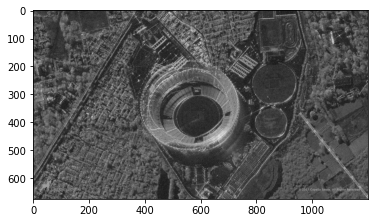

In [47]:
plt.imshow(image_gray, cmap="gray")

In [81]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[229,   0,   0, ...,   0,   0,   0],
       [126,  68,   0, ...,   0,   0,  32],
       [162,  11,   6, ...,  13,  50,   0],
       ...,
       [  0,   6, 141, ...,   0,   0, 105],
       [ 26,   0,   0, ...,  54,  99,   0],
       [ 30,   0,  14, ...,   0,  84,   0]], dtype=uint8)

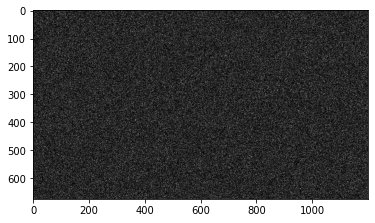

In [82]:
plt.imshow(noise_gauss, cmap="gray")

In [83]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [84]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [85]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

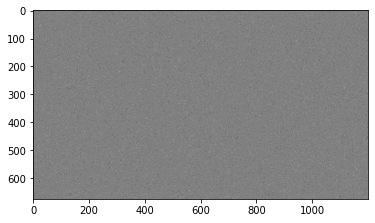

In [86]:
plt.imshow(bg_image, cmap="gray")

In [87]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

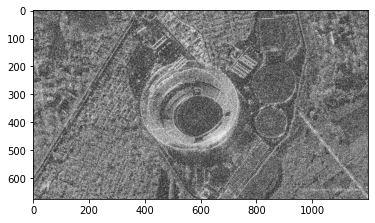

In [88]:
plt.imshow(image_noise_gauss, cmap="gray")

In [89]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

4239.23434691358 0.18694949978788222


In [90]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [91]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

In [92]:
print(mse_gauss_median, ssim_gauss_median)

1034.030974074074 0.42729854374617976


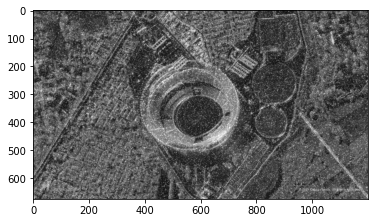

In [93]:
plt.imshow(image_gauss_median, cmap="gray")

In [94]:
import copy

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

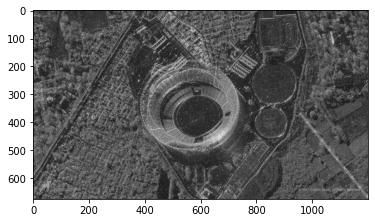

In [95]:
plt.imshow(image_sp, cmap="gray")

In [96]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

387.02924320987654 0.7229272028218258


In [101]:
image_sp_median = cv2.medianBlur(image_sp, 3)

In [102]:
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

95.94404444444444 0.8160796293211554


# Другие типы фильтров

In [131]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

In [133]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [139]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [147]:
import math

def geom(a):
    prod = 1
    for i in range(a.shape[0]):
        prod1 = 1
        for j in range(a.shape[1]):
            prod1 *= a[i,j]
        prod1 = math.pow(prod1, 1.0/9.0)
        prod *= prod1
    return prod

def proc(img, filter):
    img_res = copy.deepcopy(img)
    for i in range(0,img.shape[0] -2):
        for j in range(0,img.shape[1] -2):
            img_res[i:i+3, j:j+3] = filter(img[i:i+3, j:j+3])
    return img_res
    
res = proc(image_noise_gauss, geom)


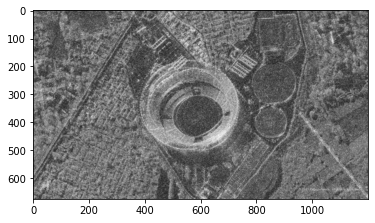

In [148]:
plt.imshow(res, cmap="gray")

In [149]:
mse_geom = mean_squared_error(image_gray, res)
(ssim_geom, diff) = structural_similarity(image_gray, res, full=True)
print(mse_geom, ssim_geom)

1219.7879691358025 0.3984170557811386



# 2D свертка

In [105]:
# averaging filter
kernel_5 = np.ones((5,5),np.float32)/25
image_k5 = cv2.filter2D(image_gray,-1,kernel_5)
# blured_image = cv2.blur(img,(5,5))
image_b5 = cv2.blur(image_gray,(5,5))

In [106]:
mse_kb = mean_squared_error(image_k5, image_b5)
(ssim_kb, diff) = structural_similarity(image_k5, image_b5, full=True)
print(mse_kb, ssim_kb)

0.0 1.0


In [127]:
# Laplasian
kernel_lapl = np.array([[0,-10,0],
                        [-10,40,-10],
                        [0,-10,0]], np.float32)

In [128]:
image_lapl = cv2.filter2D(image_gray,-1,kernel_lapl) 

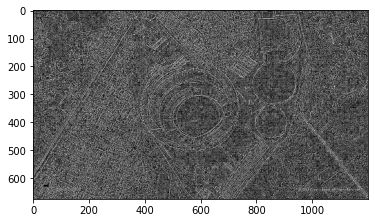

In [129]:
plt.imshow(image_lapl, cmap="gray")

In [ ]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [3]:
image = cv2.imread('paris.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

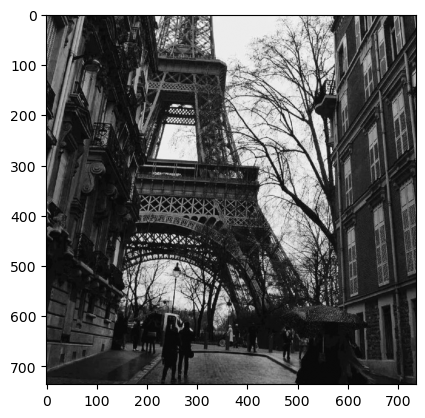

In [4]:
plt.imshow(image_gray, cmap="gray")

In [5]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ...,   0,  32,   5],
       [ 46,  83, 118, ...,  40,   0, 100],
       [149,  60,   0, ..., 242,   0,   0],
       ...,
       [  2,   4,   0, ...,   0,  10,   0],
       [  0,   0,  81, ..., 117,  95, 122],
       [  0,  63,   0, ...,   9,  26,   0]], shape=(736, 736), dtype=uint8)

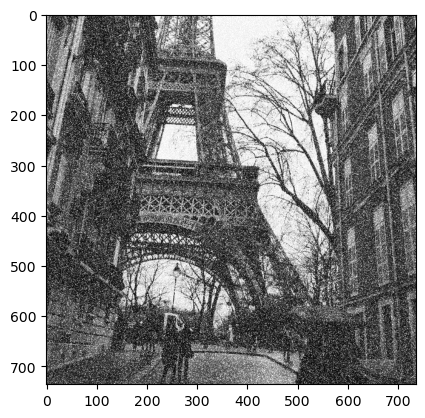

In [6]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

In [7]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [8]:
import copy
image_sp = copy.deepcopy(image_gray)

In [9]:
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

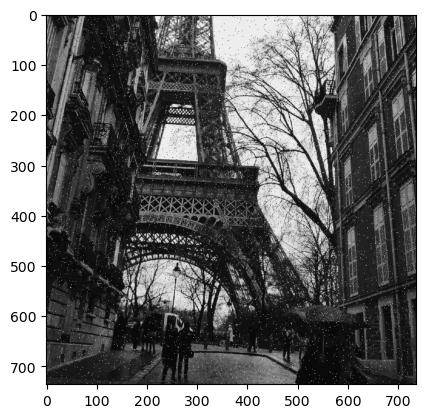

In [10]:
plt.imshow(image_sp, cmap="gray")

In [22]:
noise_constant = np.random.uniform(-50, 50, image_gray.shape).astype(np.int16)

In [23]:
image_noise_constant = image_gray.astype(np.int16) + noise_constant
image_noise_constant = np.clip(image_noise_constant, 0, 255).astype(np.uint8)

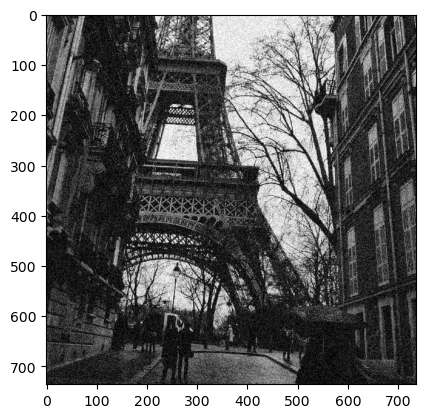

In [24]:
plt.imshow(image_noise_constant, cmap="gray")

3 1223.0573125886106 0.45514693225909264


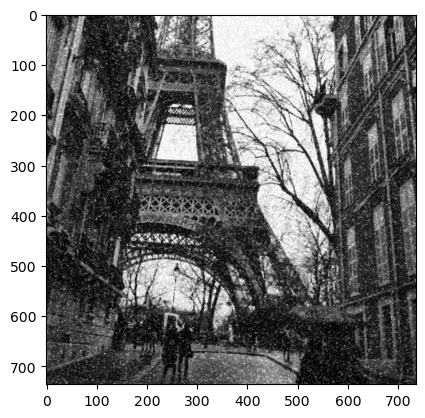

5 1154.097757782963 0.4476427631001137


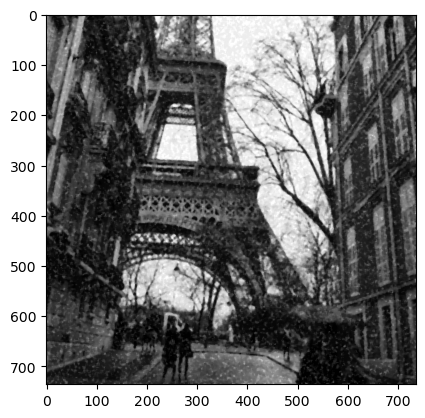

7 1286.1953826500473 0.40816657273338103


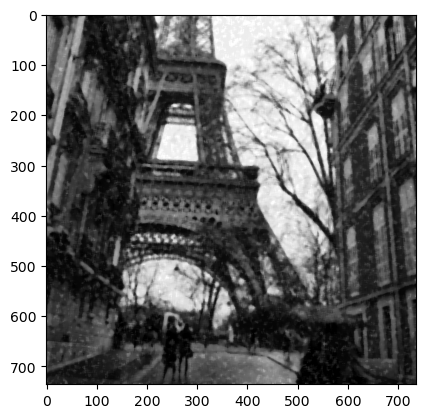

In [14]:
from skimage.metrics import structural_similarity, mean_squared_error

for k in [3, 5, 7]:
    image_median = cv2.medianBlur(image_noise_gauss, k)
    mse = mean_squared_error(image_gray, image_median)
    (ssim, diff) = structural_similarity(image_gray, image_median, full=True)
    print(k, mse, ssim)
    plt.imshow(image_median, cmap="gray")
    plt.show()

3 1866.387562396621 0.46551709075357084


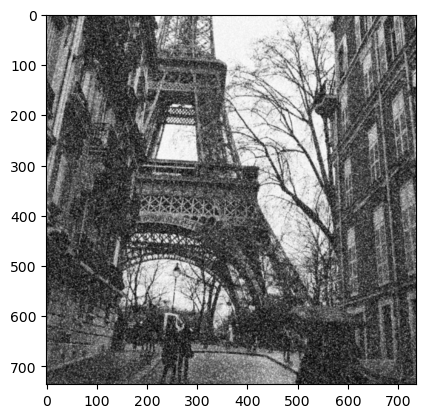

5 1820.3261220315453 0.47117750225481136


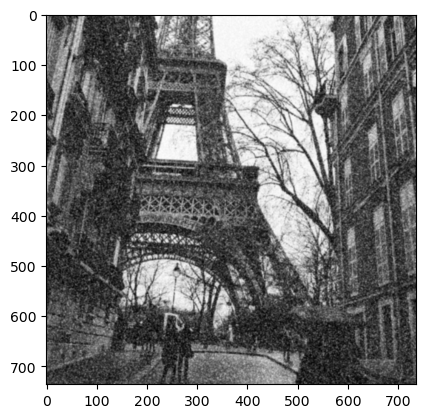

9 1937.77616227552 0.43341499501575964


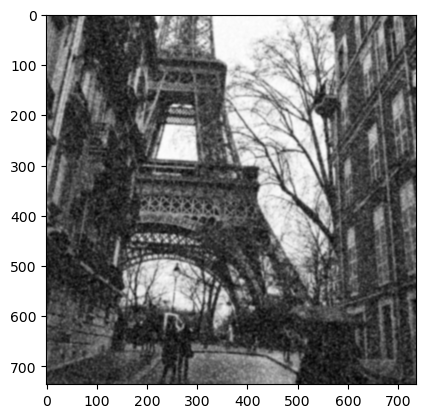

In [15]:
for k in [3, 5, 9]:
    image_gauss = cv2.GaussianBlur(image_noise_gauss, (k, k), 0)
    mse = mean_squared_error(image_gray, image_gauss)
    (ssim, diff) = structural_similarity(image_gray, image_gauss, full=True)
    print(k, mse, ssim)
    plt.imshow(image_gauss, cmap="gray")
    plt.show()

5 50 2807.602790125827 0.35317072032413643


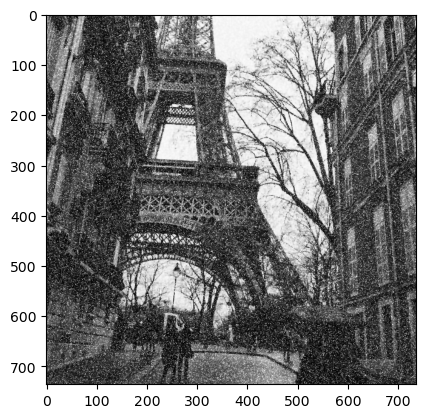

9 75 1943.1758274013469 0.3754077509805516


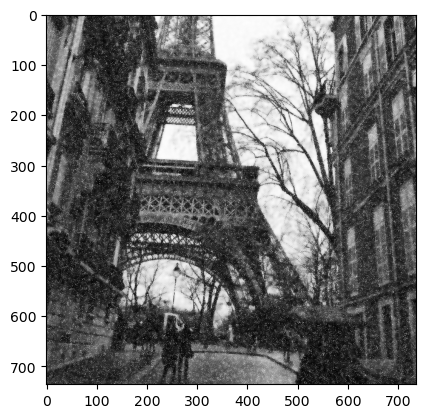

15 100 1814.2278288929583 0.3570286051452645


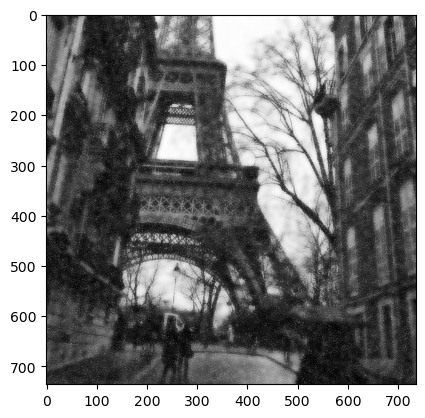

In [16]:
for d, sigma in [(5, 50), (9, 75), (15, 100)]:
    img_bil = cv2.bilateralFilter(image_noise_gauss, d, sigma, sigma)
    mse = mean_squared_error(image_gray, img_bil)
    (ssim, diff) = structural_similarity(image_gray, img_bil, full=True)
    print(d, sigma, mse, ssim)
    plt.imshow(img_bil, cmap="gray")
    plt.show()

10 3907.9391116050333 0.3180420735406193


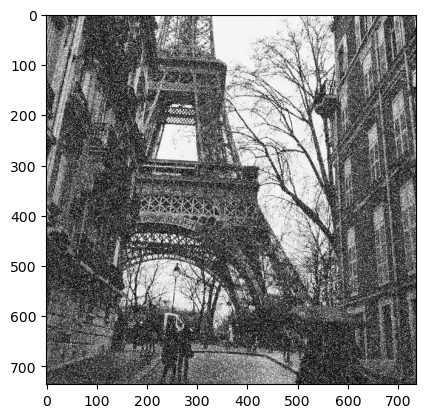

20 3903.4760659115077 0.31155712533567503


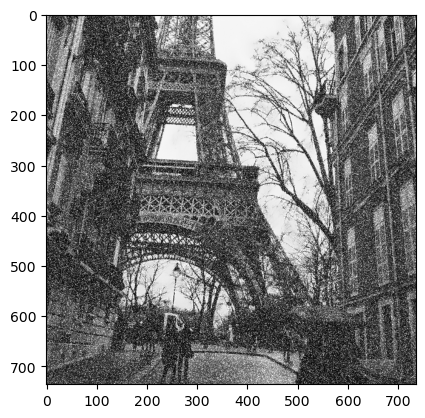

30 3135.8221271709594 0.3265935114252671


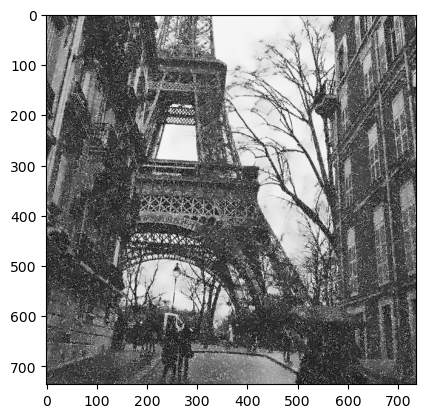

In [17]:
for h in [10, 20, 30]:
    img_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=h)
    mse = mean_squared_error(image_gray, img_nlm)
    (ssim, diff) = structural_similarity(image_gray, img_nlm, full=True)
    print(h, mse, ssim)
    plt.imshow(img_nlm, cmap="gray")
    plt.show()

3 218.41795213551512 0.8537950063836596


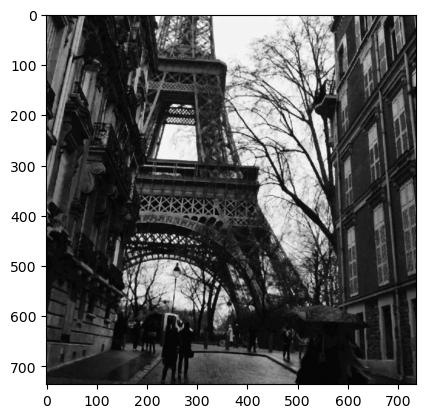

5 487.6486165672259 0.6807563023468927


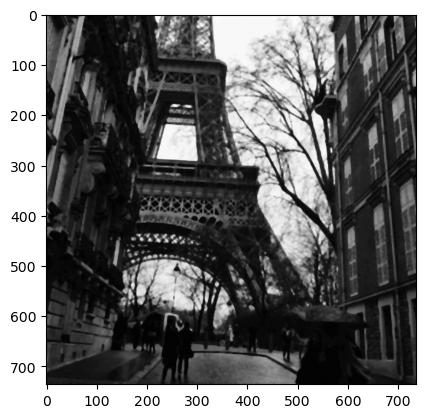

7 699.6409665199669 0.5693573832305828


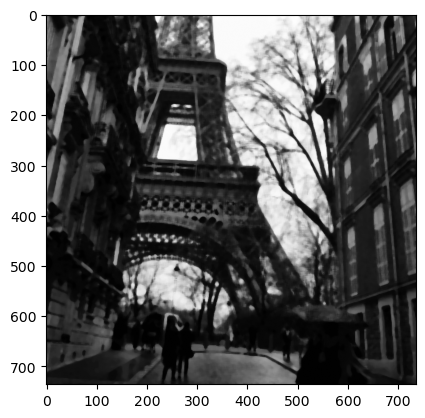

In [18]:
for k in [3, 5, 7]:
    image_median = cv2.medianBlur(image_sp, k)
    mse = mean_squared_error(image_gray, image_median)
    (ssim, diff) = structural_similarity(image_gray, image_median, full=True)
    print(k, mse, ssim)
    plt.imshow(image_median, cmap="gray")
    plt.show()

3 238.26710553520795 0.7804825353674842


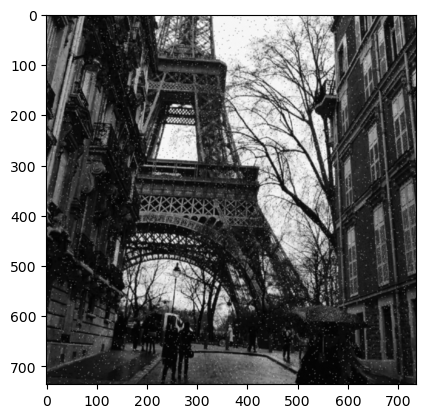

5 334.34861989012285 0.7343976816734928


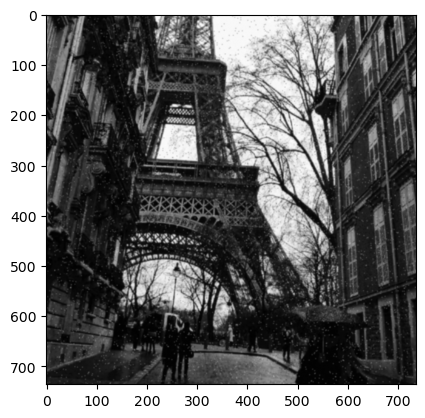

9 554.5784831344517 0.6188877716472538


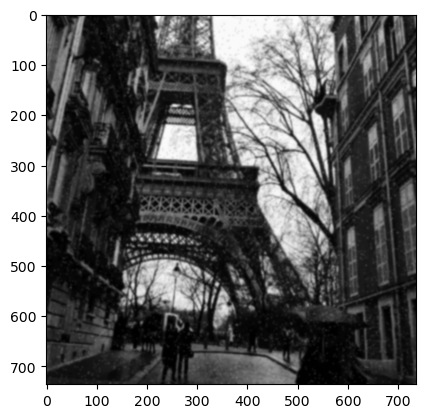

In [19]:
for k in [3, 5, 9]:
    image_gauss = cv2.GaussianBlur(image_sp, (k, k), 0)
    mse = mean_squared_error(image_gray, image_gauss)
    (ssim, diff) = structural_similarity(image_gray, image_gauss, full=True)
    print(k, mse, ssim)
    plt.imshow(image_gauss, cmap="gray")
    plt.show()

5 50 523.3568422140831 0.685133731058674


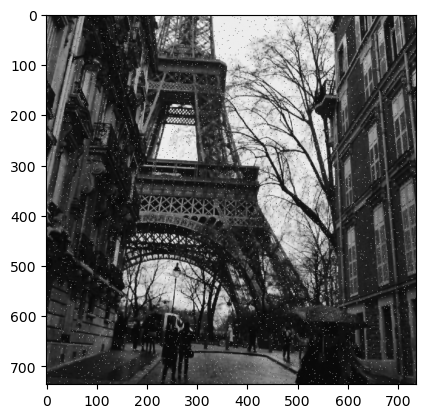

9 75 478.3683209770794 0.5853264834609129


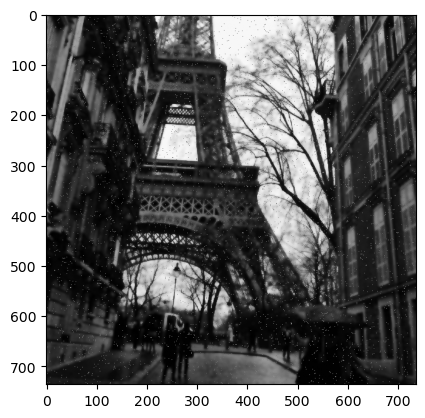

15 100 579.6094433039934 0.5098281659609397


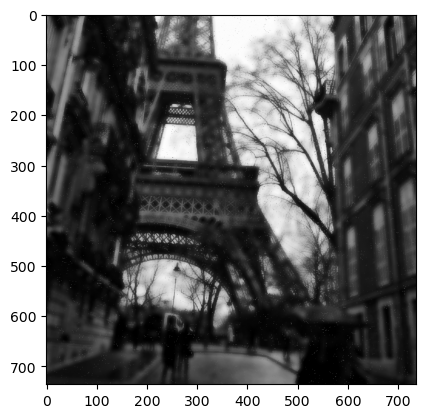

In [20]:
for d, sigma in [(5, 50), (9, 75), (15, 100)]:
    img_bil = cv2.bilateralFilter(image_sp, d, sigma, sigma)
    mse = mean_squared_error(image_gray, img_bil)
    (ssim, diff) = structural_similarity(image_gray, img_bil, full=True)
    print(d, sigma, mse, ssim)
    plt.imshow(img_bil, cmap="gray")
    plt.show()

10 472.70743922790643 0.732189618325416


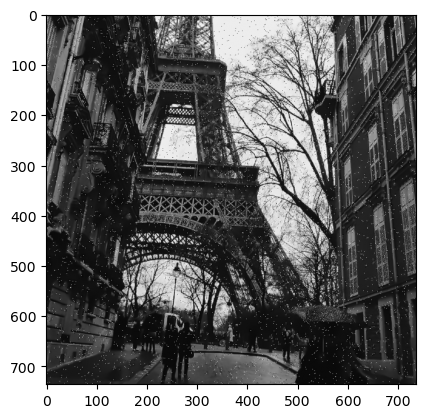

20 291.5778204011106 0.7205010979065481


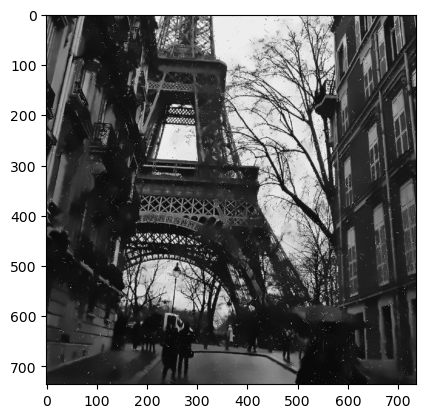

30 291.6959383122637 0.6630555271241841


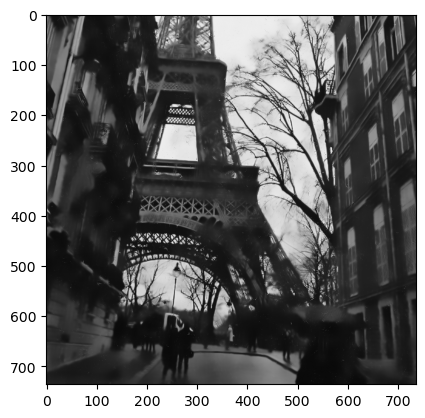

In [21]:
for h in [10, 20, 30]:
    img_nlm = cv2.fastNlMeansDenoising(image_sp, h=h)
    mse = mean_squared_error(image_gray, img_nlm)
    (ssim, diff) = structural_similarity(image_gray, img_nlm, full=True)
    print(h, mse, ssim)
    plt.imshow(img_nlm, cmap="gray")
    plt.show()

3 428.8005098800803 0.5718175842518779


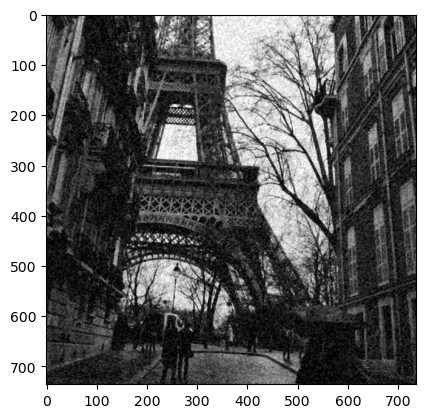

5 588.6260245599008 0.5186031543511478


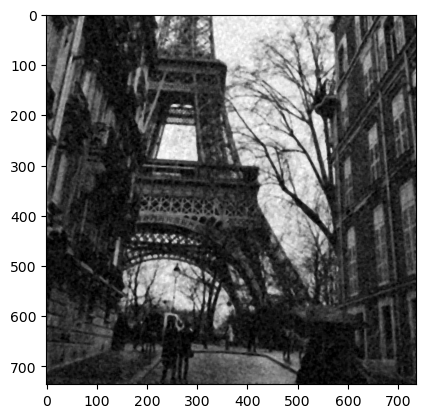

7 749.1657534853497 0.46371447222349993


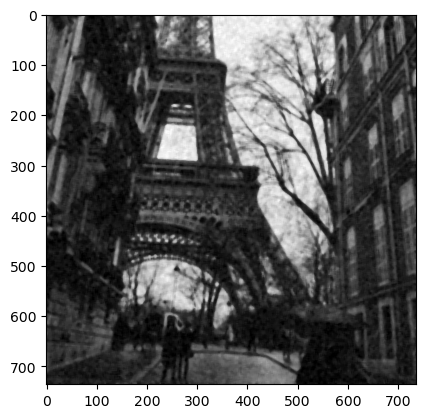

In [25]:
for k in [3, 5, 7]:
    image_uniform_median = cv2.medianBlur(image_noise_constant, k)
    mse = mean_squared_error(image_gray, image_uniform_median)
    (ssim, diff) = structural_similarity(image_gray, image_uniform_median, full=True)
    print(k, mse, ssim)
    plt.imshow(image_uniform_median, cmap="gray")
    plt.show()

3 278.7026985615548 0.6971027155560904


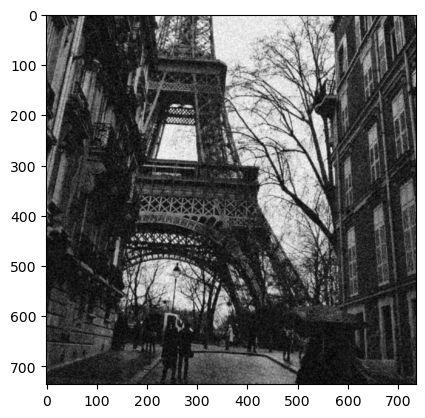

5 361.47301623050566 0.686170221609512


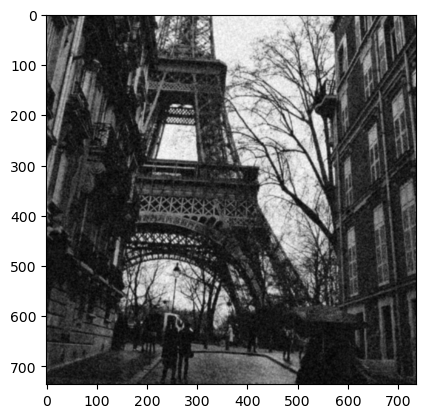

9 572.1634846851371 0.597100672135975


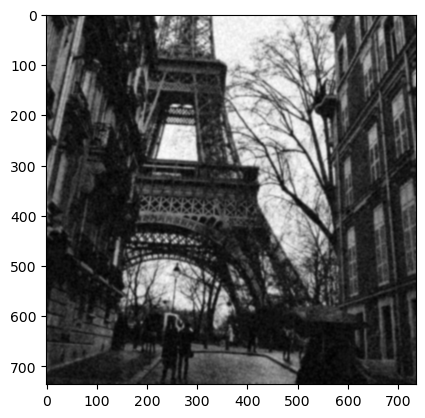

In [26]:
for k in [3, 5, 9]:
    image_uniform_gauss = cv2.GaussianBlur(image_noise_constant, (k, k), 0)
    mse = mean_squared_error(image_gray, image_uniform_gauss)
    (ssim, diff) = structural_similarity(image_gray, image_uniform_gauss, full=True)
    print(k, mse, ssim)
    plt.imshow(image_uniform_gauss, cmap="gray")
    plt.show()

5 50 245.8782952061673 0.7059139871215184


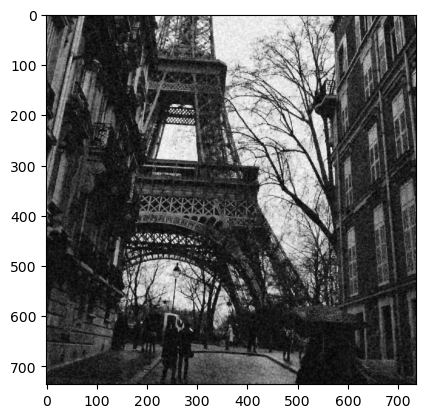

9 75 333.54862505907374 0.6766390375602438


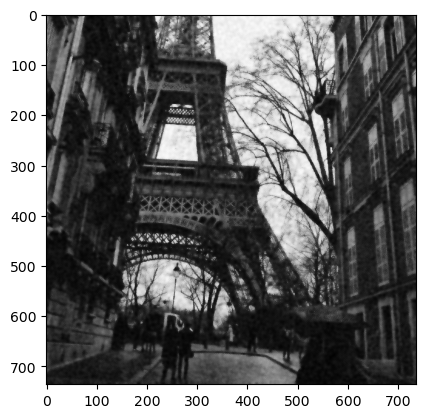

15 100 564.7298595522212 0.5511919964643318


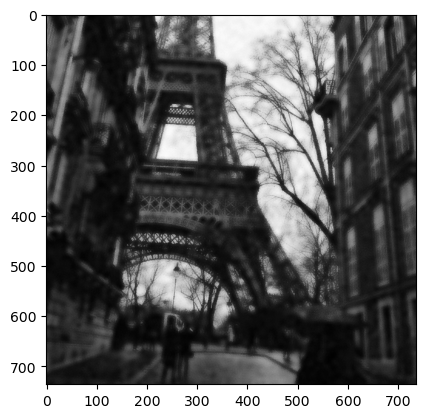

In [27]:
for d, sigma in [(5, 50), (9, 75), (15, 100)]:
    image_uniform_bilat = cv2.bilateralFilter(image_noise_constant, d, sigma, sigma)
    mse = mean_squared_error(image_gray, image_uniform_bilat)
    (ssim, diff) = structural_similarity(image_gray, image_uniform_bilat, full=True)
    print(d, sigma, mse, ssim)
    plt.imshow(image_uniform_bilat, cmap="gray")
    plt.show()

10 678.6162700112241 0.5071086990071921


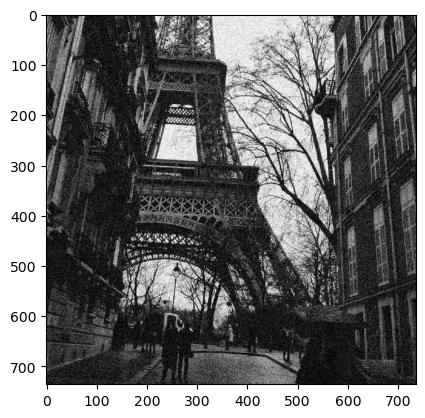

20 317.1617290879017 0.725359746657889


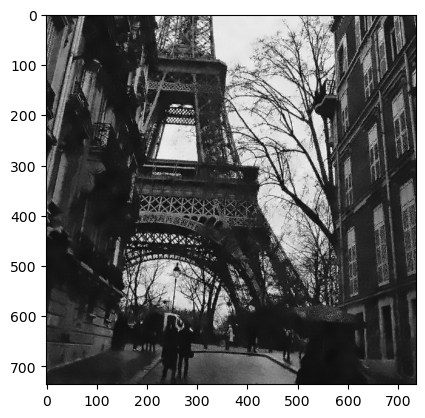

30 294.34994904891306 0.6649887023949607


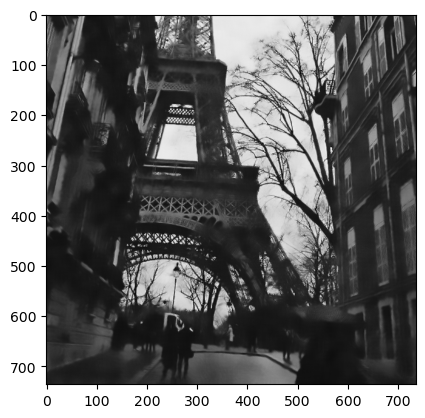

In [28]:
for h in [10, 20, 30]:
    image_uniform_nlm = cv2.fastNlMeansDenoising(image_noise_constant, h=h)
    mse = mean_squared_error(image_gray, image_uniform_nlm)
    (ssim, diff) = structural_similarity(image_gray, image_uniform_nlm, full=True)
    print(h, mse, ssim)
    plt.imshow(image_uniform_nlm, cmap="gray")
    plt.show()